In [ ]:
#!/usr/bin/env python3

import os
import math
import argparse
import random
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt


def get_config(name: str) -> Dict[str, Any]:
    base = dict(
        seed=0,
        device="cuda",
        data_path="./data",
        batch_size=128,
        lr=0.1,
        momentum=0.9,
        weight_decay=5e-4,
        max_iterations=20000,
        eval_every=200,      
        patience_evals=30,      
        train_size=55000,
        val_size=5000,

        model_name="conv4",
        model_kwargs=dict(in_channels=1, num_classes=10, width=64),

        sparsities=[1.0, 0.5, 0.2, 0.1, 0.05],  
        trials=3,

        iterative_rounds=5,      
        results_dir="./results/conv4/minimal",
    )

    if name == "test":
        base.update(
            max_iterations=3000,
            eval_every=100,
            patience_evals=10,
            trials=1,
            sparsities=[1.0, 0.2],
            results_dir="./results/conv4/test",
        )
    elif name == "minimal":
        base.update(
            max_iterations=10000,
            eval_every=200,
            patience_evals=20,
            trials=2,
            sparsities=[1.0, 0.5, 0.2, 0.1],
            iterative_rounds=4,
            results_dir="./results/conv4/minimal",
        )
    elif name == "full":
        base.update(
            max_iterations=20000,
            eval_every=200,
            patience_evals=30,
            trials=5,
            sparsities=[1.0, 0.7, 0.5, 0.35, 0.2, 0.1, 0.05],
            iterative_rounds=7,
            results_dir="./results/conv4/full",
        )
    elif name == "paper_same":
        base.update(
            max_iterations=20000,
            eval_every=200,
            patience_evals=30,
            trials=10,
            sparsities=[1.0, 0.8, 0.64, 0.512, 0.4096, 0.32768, 0.262144, 0.2097152, 0.16777216, 0.134217728],
            iterative_rounds=10,
            results_dir="./results/conv4/paper_same",
        )
    else:
        raise ValueError(f"Unknown config: {name}")

    return base

class Conv4(nn.Module):
 
    def __init__(self, num_classes=10, in_channels=1, width=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, width, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(width, width, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 28->14

            nn.Conv2d(width, 2*width, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(2*width, 2*width, 3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14->7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2*width * 7 * 7, 256), nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def build_model(model_name: str, **kwargs) -> nn.Module:
    if model_name.lower() == "conv4":
        return Conv4(**kwargs)
    raise ValueError(f"Unknown model_name={model_name}")


def init_weights_xavier(model: nn.Module):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device(device_str: str) -> torch.device:
    if device_str == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def load_mnist(data_path: str, train_size: int, val_size: int, batch_size: int, seed: int):
    tfm = transforms.Compose([transforms.ToTensor()])
    full_train = datasets.MNIST(root=data_path, train=True, download=True, transform=tfm)
    test_set = datasets.MNIST(root=data_path, train=False, download=True, transform=tfm)

    max_train = len(full_train)
    train_size = min(train_size, max_train - val_size)
    val_size = min(val_size, max_train - train_size)

    train_set, val_set = random_split(full_train, [train_size, val_size],
                                      generator=torch.Generator().manual_seed(seed))

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader


@torch.no_grad()
def accuracy(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / max(total, 1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def named_prunable_params(model: nn.Module):

    for name, p in model.named_parameters():
        if p.requires_grad and p.dim() >= 2 and "weight" in name:
            yield name, p


def make_ones_mask(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {n: torch.ones_like(p, dtype=torch.float32) for n, p in named_prunable_params(model)}


def apply_mask_(model: nn.Module, mask: Dict[str, torch.Tensor]):
    with torch.no_grad():
        for n, p in named_prunable_params(model):
            p.mul_(mask[n].to(p.device))


def masked_parameters(model: nn.Module, mask: Dict[str, torch.Tensor]):

    return [p for _, p in model.named_parameters() if p.requires_grad]


def global_magnitude_prune_mask(
    model: nn.Module,
    current_mask: Dict[str, torch.Tensor],
    target_keep_fraction: float
) -> Dict[str, torch.Tensor]:

    total_prunable = 0
    for n, p in named_prunable_params(model):
        total_prunable += current_mask[n].numel()

    all_scores = []
    per_param = [] 
    for n, p in named_prunable_params(model):
        w = p.detach().abs()
        m = current_mask[n].detach()

        w = torch.nan_to_num(w, nan=0.0, posinf=0.0, neginf=0.0)

        active = (m > 0)
        if active.any():
            scores = w[active].flatten()
            scores = scores[torch.isfinite(scores)]
            if scores.numel() > 0:
                all_scores.append(scores)

        per_param.append((n, w, m))

    if len(all_scores) == 0:
        return {k: v.clone() for k, v in current_mask.items()}

    all_scores = torch.cat(all_scores)
    active_count = all_scores.numel()

    desired_keep = int(math.ceil(target_keep_fraction * total_prunable))
    desired_keep = max(1, min(desired_keep, total_prunable))

    if active_count <= desired_keep:
        return {k: v.clone() for k, v in current_mask.items()}

    prune_count = active_count - desired_keep
    prune_count = max(1, min(prune_count, active_count - 1))

    thresh = torch.kthvalue(all_scores, prune_count).values

    if not torch.isfinite(thresh):
        return {k: v.clone() for k, v in current_mask.items()}

    thresh_val = thresh.item()

    new_mask = {}
    for n, w, m in per_param:
        active = (m > 0)
        nm = m.clone()
        nm[active & (w <= thresh_val)] = 0.0
        new_mask[n] = nm.float()

    new_active = sum(int((v > 0).sum().item()) for v in new_mask.values())
    if new_active == 0:
        return {k: v.clone() for k, v in current_mask.items()}

    return new_mask


def random_sparse_mask_like(model: nn.Module, keep_fraction: float, seed: int) -> Dict[str, torch.Tensor]:

    g = torch.Generator().manual_seed(seed)
    mask = {}
    for n, p in named_prunable_params(model):
        num = p.numel()
        keep = int(math.ceil(keep_fraction * num))
        keep = max(1, min(keep, num))
        # sample indices to keep
        idx = torch.randperm(num, generator=g)[:keep]
        m = torch.zeros(num, dtype=torch.float32)
        m[idx] = 1.0
        mask[n] = m.view_as(p)
    return mask

@dataclass
class TrainResult:
    early_stop_iter: int
    early_stop_val_acc: float
    early_stop_test_acc: float
    train_acc_at_early_stop: float
    learning_curve: Dict[str, List[float]]  


def train_with_early_stop(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    device: torch.device,
    max_iterations: int,
    eval_every: int,
    patience_evals: int,
    lr: float,
    momentum: float,
    weight_decay: float,
    mask: Dict[str, torch.Tensor] = None
) -> TrainResult:
    model.to(device)
    model.train()

    criterion = nn.CrossEntropyLoss()
    opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    curve_iters = []
    curve_val = []
    curve_test = []
    curve_train = []

    best_val = -1e9
    best_iter = 0
    best_test = 0.0
    best_train = 0.0
    no_improve = 0

    it = 0
    loader_iter = iter(train_loader)

    while it < max_iterations:
        try:
            x, y = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            x, y = next(loader_iter)

        x, y = x.to(device), y.to(device)

        opt.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        opt.step()

        if mask is not None:
            apply_mask_(model, mask)

        it += 1

        if it % eval_every == 0 or it == 1:
            tr_acc = accuracy(model, train_loader, device)
            va_acc = accuracy(model, val_loader, device)
            te_acc = accuracy(model, test_loader, device)

            curve_iters.append(it)
            curve_train.append(tr_acc)
            curve_val.append(va_acc)
            curve_test.append(te_acc)

            if va_acc > best_val + 1e-6:
                best_val = va_acc
                best_iter = it
                best_test = te_acc
                best_train = tr_acc
                no_improve = 0
            else:
                no_improve += 1

            if no_improve >= patience_evals:
                break

    return TrainResult(
        early_stop_iter=best_iter,
        early_stop_val_acc=best_val,
        early_stop_test_acc=best_test,
        train_acc_at_early_stop=best_train,
        learning_curve=dict(
            iterations=curve_iters,
            val_accs=curve_val,
            test_accs=curve_test,
            train_accs=curve_train,
        )
    )


def make_fresh_model(config: Dict[str, Any], device: torch.device) -> nn.Module:
    m = build_model(config["model_name"], **config.get("model_kwargs", {}))
    init_weights_xavier(m)
    return m.to(device)


def clone_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().clone() for k, v in model.state_dict().items()}


def load_state_dict_(model: nn.Module, state: Dict[str, torch.Tensor]):
    model.load_state_dict(state, strict=True)


def exp1_random_sparse(config, loaders, device) -> Dict[float, List[Dict[str, Any]]]:
    train_loader, val_loader, test_loader = loaders
    results = {}
    for s in config["sparsities"]:
        trials_out = []
        for t in range(config["trials"]):
            model = make_fresh_model(config, device)
            init_state = clone_state_dict(model)

            if s < 1.0:
                mask = random_sparse_mask_like(model, keep_fraction=s, seed=config["seed"] + 1000 + t + int(s*10000))
                apply_mask_(model, mask)
            else:
                mask = None

            res = train_with_early_stop(
                model, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=mask
            )

            trials_out.append(dict(
                early_stop_iter=res.early_stop_iter,
                early_stop_test_acc=res.early_stop_test_acc,
                train_acc_at_early_stop=res.train_acc_at_early_stop,
                learning_curve=res.learning_curve
            ))
        results[s] = trials_out
    return results


def exp2_oneshot_winning(config, loaders, device) -> Dict[float, List[Dict[str, Any]]]:
    train_loader, val_loader, test_loader = loaders
    results = {}
    for s in config["sparsities"]:
        trials_out = []
        for t in range(config["trials"]):

            model = make_fresh_model(config, device)
            init_state = clone_state_dict(model)

            dense_res = train_with_early_stop(
                model, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=None
            )

            if s < 1.0:
                current_mask = make_ones_mask(model)
                mask = global_magnitude_prune_mask(model, current_mask, target_keep_fraction=s)
            else:
                mask = None

            model2 = make_fresh_model(config, device)
            load_state_dict_(model2, init_state)
            if mask is not None:
                apply_mask_(model2, mask)

            res = train_with_early_stop(
                model2, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=mask
            )

            trials_out.append(dict(
                early_stop_iter=res.early_stop_iter,
                early_stop_test_acc=res.early_stop_test_acc,
                train_acc_at_early_stop=res.train_acc_at_early_stop,
                learning_curve=res.learning_curve,
                mask=mask  
            ))
        results[s] = trials_out
    return results


def exp3_iterative_winning(config, loaders, device) -> Dict[float, List[Dict[str, Any]]]:

    train_loader, val_loader, test_loader = loaders
    results = {}
    rounds = config["iterative_rounds"]

    for s in config["sparsities"]:
        trials_out = []
        for t in range(config["trials"]):
            base_model = make_fresh_model(config, device)
            init_state = clone_state_dict(base_model)

            mask = make_ones_mask(base_model)

            if abs(s - 1.0) < 1e-12:
                model = make_fresh_model(config, device)
                load_state_dict_(model, init_state)
                res = train_with_early_stop(
                    model, train_loader, val_loader, test_loader, device,
                    max_iterations=config["max_iterations"],
                    eval_every=config["eval_every"],
                    patience_evals=config["patience_evals"],
                    lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                    mask=None
                )
                trials_out.append(dict(
                    early_stop_iter=res.early_stop_iter,
                    early_stop_test_acc=res.early_stop_test_acc,
                    train_acc_at_early_stop=res.train_acc_at_early_stop,
                    learning_curve=res.learning_curve,
                    mask=None
                ))
                results[s] = trials_out
                continue

            keep_targets = np.geomspace(1.0, s, num=rounds+1)[1:] 

            for kr in keep_targets:
                model = make_fresh_model(config, device)
                load_state_dict_(model, init_state)
                apply_mask_(model, mask)

                _ = train_with_early_stop(
                    model, train_loader, val_loader, test_loader, device,
                    max_iterations=config["max_iterations"],
                    eval_every=config["eval_every"],
                    patience_evals=config["patience_evals"],
                    lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                    mask=mask
                )

                mask = global_magnitude_prune_mask(model, mask, target_keep_fraction=kr)

            final_model = make_fresh_model(config, device)
            load_state_dict_(final_model, init_state)
            apply_mask_(final_model, mask)
            res = train_with_early_stop(
                final_model, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=mask
            )

            trials_out.append(dict(
                early_stop_iter=res.early_stop_iter,
                early_stop_test_acc=res.early_stop_test_acc,
                train_acc_at_early_stop=res.train_acc_at_early_stop,
                learning_curve=res.learning_curve,
                mask=mask 
            ))

        results[s] = trials_out
    return results


def exp4_oneshot_reinit(config, loaders, device, exp2_results) -> Dict[float, List[Dict[str, Any]]]:

    train_loader, val_loader, test_loader = loaders
    results = {}
    for s in config["sparsities"]:
        if s not in exp2_results:
            continue
        trials_out = []
        for t in range(len(exp2_results[s])):
            mask = exp2_results[s][t].get("mask", None)
            model = make_fresh_model(config, device) 
            if mask is not None:
                apply_mask_(model, mask)
            res = train_with_early_stop(
                model, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=mask
            )
            trials_out.append(dict(
                early_stop_iter=res.early_stop_iter,
                early_stop_test_acc=res.early_stop_test_acc,
                train_acc_at_early_stop=res.train_acc_at_early_stop,
                learning_curve=res.learning_curve
            ))
        results[s] = trials_out
    return results


def exp5_iterative_reinit(config, loaders, device, exp3_results) -> Dict[float, List[Dict[str, Any]]]:

    train_loader, val_loader, test_loader = loaders
    results = {}
    for s in config["sparsities"]:
        if s not in exp3_results:
            continue
        trials_out = []
        for t in range(len(exp3_results[s])):
            mask = exp3_results[s][t].get("mask", None)
            model = make_fresh_model(config, device) 
            if mask is not None:
                apply_mask_(model, mask)
            res = train_with_early_stop(
                model, train_loader, val_loader, test_loader, device,
                max_iterations=config["max_iterations"],
                eval_every=config["eval_every"],
                patience_evals=config["patience_evals"],
                lr=config["lr"], momentum=config["momentum"], weight_decay=config["weight_decay"],
                mask=mask
            )
            trials_out.append(dict(
                early_stop_iter=res.early_stop_iter,
                early_stop_test_acc=res.early_stop_test_acc,
                train_acc_at_early_stop=res.train_acc_at_early_stop,
                learning_curve=res.learning_curve
            ))
        results[s] = trials_out
    return results


def ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def save_pt(obj: Any, path: str):
    ensure_dir(os.path.dirname(path))
    torch.save(obj, path)


def load_pt(path: str) -> Any:
    return torch.load(path, weights_only=False)


def plot_figure1(exp1_results, exp2_results, output_path):
    print("\nGenerating Figure 1...")

    sparsities = sorted(exp1_results.keys(), reverse=True)
    sparsities_pct = [s * 100 for s in sparsities]

    def collect(res_dict):
        early, acc, early_err, acc_err = [], [], [], []
        for s in sparsities:
            trials = res_dict[s]
            early_stops = [t["early_stop_iter"] for t in trials]
            test_accs = [t["early_stop_test_acc"] for t in trials]
            early.append(np.mean(early_stops))
            acc.append(np.mean(test_accs))
            early_err.append(np.std(early_stops) if len(trials) > 1 else 0)
            acc_err.append(np.std(test_accs) if len(trials) > 1 else 0)
        return early, acc, early_err, acc_err

    random_early, random_acc, random_early_err, random_acc_err = collect(exp1_results)
    win_early, win_acc, win_early_err, win_acc_err = collect(exp2_results)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.errorbar(sparsities_pct, random_early, yerr=random_early_err,
                 fmt='o--', linewidth=2, markersize=7, capsize=5,
                 label='Random Sparse', alpha=0.85)
    ax1.errorbar(sparsities_pct, win_early, yerr=win_early_err,
                 fmt='s-', linewidth=2, markersize=7, capsize=5,
                 label='Winning Tickets', alpha=0.85)
    ax1.set_xlabel('Percent of Weights Remaining (%)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Early-Stop Iteration (Val.)', fontsize=12, fontweight='bold')
    ax1.set_title('Learning Speed vs Sparsity', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(fontsize=10, loc='best')
    ax1.invert_xaxis()

    ax2.errorbar(sparsities_pct, random_acc, yerr=random_acc_err,
                 fmt='o--', linewidth=2, markersize=7, capsize=5,
                 label='Random Sparse', alpha=0.85)
    ax2.errorbar(sparsities_pct, win_acc, yerr=win_acc_err,
                 fmt='s-', linewidth=2, markersize=7, capsize=5,
                 label='Winning Tickets', alpha=0.85)
    ax2.set_xlabel('Percent of Weights Remaining (%)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Test Accuracy at Early-Stop (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Test Accuracy vs Sparsity', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, linestyle='--')
    ax2.legend(fontsize=10, loc='best')
    ax2.invert_xaxis()

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved Figure 1 to {output_path}")
    plt.close()


def plot_figure3(exp3_results, exp5_results, output_path):
    print("\nGenerating Figure 3...")

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    sparsities = sorted([s for s in exp3_results.keys() if s < 1.0], reverse=True)

    def get_accs(lc):
        return lc.get("val_accs", lc.get("test_accs", []))

    for sp in sparsities:
        trials = exp3_results[sp]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        mask = np.array(iters) <= 15000
        ax1.plot(np.array(iters)[mask], avg[mask], linewidth=2, label=f"{sp*100:.1f}%", alpha=0.85)

    if 1.0 in exp3_results:
        trials = exp3_results[1.0]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        mask = np.array(iters) <= 15000
        ax1.plot(np.array(iters)[mask], avg[mask], linewidth=2.5, label="100% (original)", color="black", alpha=0.9)

    ax1.set_xlabel("Training Iterations", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Validation Accuracy (%)", fontsize=12, fontweight="bold")
    ax1.set_title("Acceleration Phase", fontsize=13, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9, loc="lower right")
    ax1.set_xlim(0, 15000)

    for sp in sparsities:
        trials = exp3_results[sp]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        ax2.plot(iters, avg, linewidth=2, label=f"{sp*100:.1f}%", alpha=0.85)

    if 1.0 in exp3_results:
        trials = exp3_results[1.0]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        ax2.plot(iters, avg, linewidth=2.5, label="100% (original)", color="black", alpha=0.9)

    ax2.set_xlabel("Training Iterations", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Validation Accuracy (%)", fontsize=12, fontweight="bold")
    ax2.set_title("Full Training", fontsize=13, fontweight="bold")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9, loc="lower right")

    reinit_sps = sorted(exp5_results.keys(), reverse=True)
    for sp in reinit_sps:
        if sp in exp3_results:
            trials = exp3_results[sp]
            curves = [get_accs(t["learning_curve"]) for t in trials]
            avg = np.mean(curves, axis=0)
            iters = trials[0]["learning_curve"]["iterations"]
            ax3.plot(iters, avg, linewidth=2.5, label=f"{sp*100:.1f}% winning", alpha=0.9)

        trials = exp5_results[sp]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        ax3.plot(iters, avg, linewidth=2, linestyle="--", label=f"{sp*100:.1f}% reinit", alpha=0.75)

    if 1.0 in exp3_results:
        trials = exp3_results[1.0]
        curves = [get_accs(t["learning_curve"]) for t in trials]
        avg = np.mean(curves, axis=0)
        iters = trials[0]["learning_curve"]["iterations"]
        ax3.plot(iters, avg, linewidth=2.5, label="100% (original)", color="black", alpha=0.9)

    ax3.set_xlabel("Training Iterations", fontsize=12, fontweight="bold")
    ax3.set_ylabel("Validation Accuracy (%)", fontsize=12, fontweight="bold")
    ax3.set_title("Winning vs Random Reinit", fontsize=13, fontweight="bold")
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9, loc="lower right")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"✓ Saved Figure 3 to {output_path}")
    plt.close()


def plot_figure4a(exp2_results, exp3_results, exp4_results, exp5_results, output_path):
    print("\nGenerating Figure 4a...")

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    oneshot_sps = sorted(exp2_results.keys(), reverse=True)
    iterative_sps = sorted(exp3_results.keys(), reverse=True)

    def mean_std(trials, key):
        vals = [t[key] for t in trials]
        return np.mean(vals), (np.std(vals) if len(vals) > 1 else 0)

    osw_early, osw_early_e = [], []
    osw_acc, osw_acc_e = [], []
    osw_tr, osw_tr_e = [], []
    for s in oneshot_sps:
        m, e = mean_std(exp2_results[s], "early_stop_iter"); osw_early.append(m); osw_early_e.append(e)
        m, e = mean_std(exp2_results[s], "early_stop_test_acc"); osw_acc.append(m); osw_acc_e.append(e)
        m, e = mean_std(exp2_results[s], "train_acc_at_early_stop"); osw_tr.append(m); osw_tr_e.append(e)

    itw_early, itw_early_e = [], []
    itw_acc, itw_acc_e = [], []
    itw_tr, itw_tr_e = [], []
    for s in iterative_sps:
        m, e = mean_std(exp3_results[s], "early_stop_iter"); itw_early.append(m); itw_early_e.append(e)
        m, e = mean_std(exp3_results[s], "early_stop_test_acc"); itw_acc.append(m); itw_acc_e.append(e)
        m, e = mean_std(exp3_results[s], "train_acc_at_early_stop"); itw_tr.append(m); itw_tr_e.append(e)

    osr_sps = sorted(exp4_results.keys(), reverse=True)
    osr_early, osr_early_e = [], []
    osr_acc, osr_acc_e = [], []
    osr_tr, osr_tr_e = [], []
    for s in osr_sps:
        m, e = mean_std(exp4_results[s], "early_stop_iter"); osr_early.append(m); osr_early_e.append(e)
        m, e = mean_std(exp4_results[s], "early_stop_test_acc"); osr_acc.append(m); osr_acc_e.append(e)
        m, e = mean_std(exp4_results[s], "train_acc_at_early_stop"); osr_tr.append(m); osr_tr_e.append(e)

    itr_sps = sorted(exp5_results.keys(), reverse=True)
    itr_early, itr_early_e = [], []
    itr_acc, itr_acc_e = [], []
    itr_tr, itr_tr_e = [], []
    for s in itr_sps:
        m, e = mean_std(exp5_results[s], "early_stop_iter"); itr_early.append(m); itr_early_e.append(e)
        m, e = mean_std(exp5_results[s], "early_stop_test_acc"); itr_acc.append(m); itr_acc_e.append(e)
        m, e = mean_std(exp5_results[s], "train_acc_at_early_stop"); itr_tr.append(m); itr_tr_e.append(e)

    ax1.errorbar([s*100 for s in iterative_sps], itw_early, yerr=itw_early_e, fmt="o-", linewidth=2, capsize=4, label="Iterative Winning")
    ax1.errorbar([s*100 for s in itr_sps], itr_early, yerr=itr_early_e, fmt="s--", linewidth=2, capsize=4, label="Iterative Reinit")
    ax1.errorbar([s*100 for s in oneshot_sps], osw_early, yerr=osw_early_e, fmt="^-", linewidth=2, capsize=4, label="One-shot Winning")
    ax1.errorbar([s*100 for s in osr_sps], osr_early, yerr=osr_early_e, fmt="v--", linewidth=2, capsize=4, label="One-shot Reinit")
    ax1.set_title("Learning Speed", fontsize=13, fontweight="bold")
    ax1.set_xlabel("Percent of Weights Remaining (%)", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Early-Stop Iteration", fontsize=12, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)
    ax1.invert_xaxis()

    ax2.errorbar([s*100 for s in iterative_sps], itw_acc, yerr=itw_acc_e, fmt="o-", linewidth=2, capsize=4, label="Iterative Winning")
    ax2.errorbar([s*100 for s in itr_sps], itr_acc, yerr=itr_acc_e, fmt="s--", linewidth=2, capsize=4, label="Iterative Reinit")
    ax2.errorbar([s*100 for s in oneshot_sps], osw_acc, yerr=osw_acc_e, fmt="^-", linewidth=2, capsize=4, label="One-shot Winning")
    ax2.errorbar([s*100 for s in osr_sps], osr_acc, yerr=osr_acc_e, fmt="v--", linewidth=2, capsize=4, label="One-shot Reinit")
    ax2.set_title("Test Accuracy at Early-Stop", fontsize=13, fontweight="bold")
    ax2.set_xlabel("Percent of Weights Remaining (%)", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Test Accuracy (%)", fontsize=12, fontweight="bold")
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=9)
    ax2.invert_xaxis()

    ax3.errorbar([s*100 for s in iterative_sps], itw_tr, yerr=itw_tr_e, fmt="o-", linewidth=2, capsize=4, label="Iterative Winning")
    ax3.errorbar([s*100 for s in itr_sps], itr_tr, yerr=itr_tr_e, fmt="s--", linewidth=2, capsize=4, label="Iterative Reinit")
    ax3.errorbar([s*100 for s in oneshot_sps], osw_tr, yerr=osw_tr_e, fmt="^-", linewidth=2, capsize=4, label="One-shot Winning")
    ax3.errorbar([s*100 for s in osr_sps], osr_tr, yerr=osr_tr_e, fmt="v--", linewidth=2, capsize=4, label="One-shot Reinit")
    ax3.set_title("Train Accuracy at Early-Stop", fontsize=13, fontweight="bold")
    ax3.set_xlabel("Percent of Weights Remaining (%)", fontsize=12, fontweight="bold")
    ax3.set_ylabel("Training Accuracy (%)", fontsize=12, fontweight="bold")
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=9)
    ax3.invert_xaxis()

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"✓ Saved Figure 4a to {output_path}")
    plt.close()

def load_or_run(path: str, run_fn):
    if os.path.exists(path):
        print(f"↩ Loading existing: {path}")
        return load_pt(path)
    else:
        print(f"▶ Running and saving: {path}")
        obj = run_fn()
        save_pt(obj, path)
        return obj

def run_all(config_name: str):
    config = get_config(config_name)
    set_seed(config["seed"])
    device = get_device(config["device"])

    print("=" * 70)
    print("LOTTERY TICKET HYPOTHESIS - Conv4 (ALL-IN-ONE)")
    print("=" * 70)
    print("Config:", config_name)
    print("Device:", device)
    print("Results dir:", config["results_dir"])
    print("Max iters:", config["max_iterations"])
    print("Eval every:", config["eval_every"])
    print("Patience evals:", config["patience_evals"])
    tmp_model = build_model(config["model_name"], **config["model_kwargs"])
    print("Model params:", count_params(tmp_model))
    print("=" * 70)

    loaders = load_mnist(config["data_path"], config["train_size"], config["val_size"],
                         config["batch_size"], seed=config["seed"])

    ensure_dir(config["results_dir"])

    exp1_path = os.path.join(config["results_dir"], "exp1_random_sparse.pt")
    exp2_path = os.path.join(config["results_dir"], "exp2_oneshot_winning.pt")
    exp3_path = os.path.join(config["results_dir"], "exp3_iterative_winning.pt")
    exp4_path = os.path.join(config["results_dir"], "exp4_oneshot_reinit.pt")
    exp5_path = os.path.join(config["results_dir"], "exp5_iterative_reinit.pt")

    print("\n[Exp1] Random Sparse")
    exp1 = load_or_run(exp1_path, lambda: exp1_random_sparse(config, loaders, device))

    print("\n[Exp2] One-shot Winning")
    exp2 = load_or_run(exp2_path, lambda: exp2_oneshot_winning(config, loaders, device))

    print("\n[Exp3] Iterative Winning")
    exp3 = load_or_run(exp3_path, lambda: exp3_iterative_winning(config, loaders, device))

    print("\n[Exp4] One-shot Reinit")
    exp4 = load_or_run(exp4_path, lambda: exp4_oneshot_reinit(config, loaders, device, exp2))

    print("\n[Exp5] Iterative Reinit")
    exp5 = load_or_run(exp5_path, lambda: exp5_iterative_reinit(config, loaders, device, exp3))


def gen_figs(results_dir: str):
    figures_dir = results_dir.replace("results", "figures")
    ensure_dir(figures_dir)

    exp1 = load_pt(os.path.join(results_dir, "exp1_random_sparse.pt"))
    exp2 = load_pt(os.path.join(results_dir, "exp2_oneshot_winning.pt"))
    exp3 = load_pt(os.path.join(results_dir, "exp3_iterative_winning.pt"))
    exp4 = load_pt(os.path.join(results_dir, "exp4_oneshot_reinit.pt"))
    exp5 = load_pt(os.path.join(results_dir, "exp5_iterative_reinit.pt"))

    plot_figure1(exp1, exp2, os.path.join(figures_dir, "figure1.png"))
    plot_figure3(exp3, exp5, os.path.join(figures_dir, "figure3.png"))
    plot_figure4a(exp2, exp3, exp4, exp5, os.path.join(figures_dir, "figure4a.png"))

    print("\n✓ Figures saved to:", figures_dir)
    print("  - figure1.png")
    print("  - figure3.png")
    print("  - figure4a.png")


In [2]:
parser = argparse.ArgumentParser()

In [3]:
sub = parser.add_subparsers(dest="cmd", required=True)

In [4]:

p_run = sub.add_parser("run", help="run experiments exp1..exp5 (Conv4)")

In [5]:
p_run.add_argument("--config", type=str, default="minimal",
                   choices=["test", "minimal", "full", "paper_same"])

_StoreAction(option_strings=['--config'], dest='config', nargs=None, const=None, default='minimal', type=<class 'str'>, choices=['test', 'minimal', 'full', 'paper_same'], required=False, help=None, metavar=None)

In [6]:

p_fig = sub.add_parser("figs", help="generate figures from results dir")


In [7]:
p_fig.add_argument("--results", type=str, required=True)

_StoreAction(option_strings=['--results'], dest='results', nargs=None, const=None, default=None, type=<class 'str'>, choices=None, required=True, help=None, metavar=None)

In [8]:

p_all = sub.add_parser("all", help="run experiments then generate figures")

In [9]:
p_all.add_argument("--config", type=str, default="minimal",
                       choices=["test", "minimal", "full", "paper_same"])

_StoreAction(option_strings=['--config'], dest='config', nargs=None, const=None, default='minimal', type=<class 'str'>, choices=['test', 'minimal', 'full', 'paper_same'], required=False, help=None, metavar=None)

In [13]:
import sys
sys.argv = ["lth_conv4_allinone.py", "all", "--config", "minimal"]

In [14]:
args = parser.parse_args()

In [15]:

if args.cmd == "run":
    run_all(args.config)
elif args.cmd == "figs":
    gen_figs(args.results)
elif args.cmd == "all":
    run_all(args.config)
    cfg = get_config(args.config)
    gen_figs(cfg["results_dir"])
else:
    raise RuntimeError("Unknown command")

LOTTERY TICKET HYPOTHESIS - Conv4 (ALL-IN-ONE)
Config: minimal
Device: cuda
Results dir: ./results/conv4/minimal
Max iters: 10000
Eval every: 200
Patience evals: 20
Model params: 1867466


100%|██████████| 9.91M/9.91M [00:09<00:00, 1.01MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 194kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 625kB/s] 
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]



[Exp1] Random Sparse

[Exp2] One-shot Winning

[Exp3] Iterative Winning


IndexError: kthvalue(): Expected reduction dim 0 to have non-zero size.

In [ ]:

if args.cmd == "run":
    run_all(args.config)
elif args.cmd == "figs":
    gen_figs(args.results)
elif args.cmd == "all":
    run_all(args.config)
    cfg = get_config(args.config)
    gen_figs(cfg["results_dir"])
else:
    raise RuntimeError("Unknown command")

LOTTERY TICKET HYPOTHESIS - Conv4 (ALL-IN-ONE)
Config: minimal
Device: cuda
Results dir: ./results/conv4/minimal
Max iters: 10000
Eval every: 200
Patience evals: 20
Model params: 1867466

[Exp1] Random Sparse
↩ Loading existing: ./results/conv4/minimal\exp1_random_sparse.pt

[Exp2] One-shot Winning
↩ Loading existing: ./results/conv4/minimal\exp2_oneshot_winning.pt

[Exp3] Iterative Winning
▶ Running and saving: ./results/conv4/minimal\exp3_iterative_winning.pt

[Exp4] One-shot Reinit
▶ Running and saving: ./results/conv4/minimal\exp4_oneshot_reinit.pt

[Exp5] Iterative Reinit
▶ Running and saving: ./results/conv4/minimal\exp5_iterative_reinit.pt

Generating Figure 1...
✓ Saved Figure 1 to ./figures/conv4/minimal\figure1.png

Generating Figure 3...


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

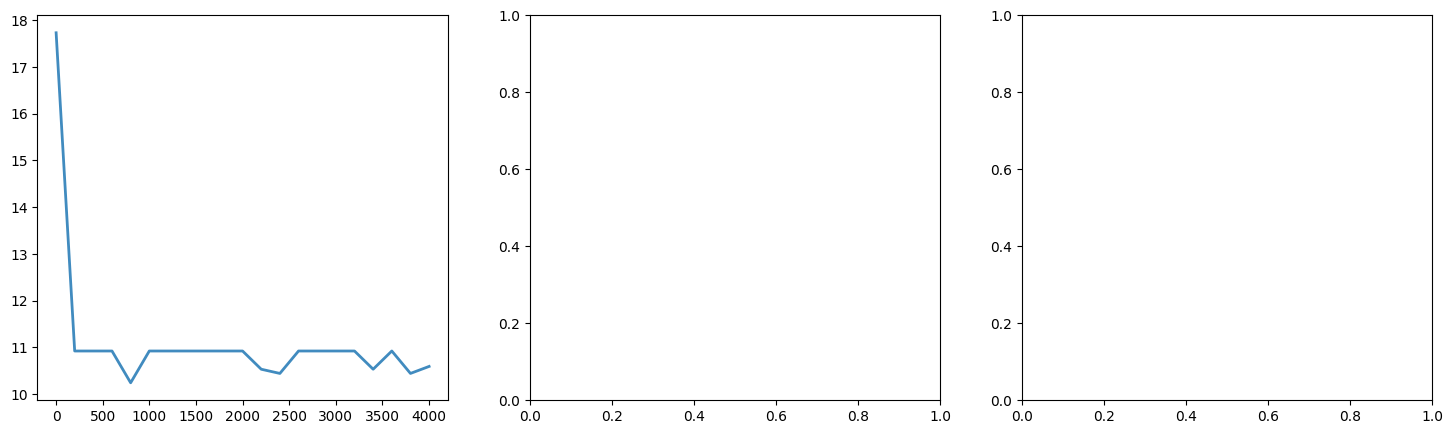

In [21]:
run_all("minimal")
cfg = get_config("minimal")
gen_figs(cfg["results_dir"])


In [ ]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt


def load_pt(path, map_location="cpu"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"PT not found: {path}")
    return torch.load(path, map_location=map_location)

def to_1d(x):
    return np.asarray(x).reshape(-1)

def get_accs_from_learning_curve(lc: dict, which="test") -> np.ndarray:

    key_map = {
        "test":  ["test_accs", "test_acc", "test_accuracy", "test_accuracies"],
        "val":   ["val_accs", "val_acc", "val_accuracy", "val_accuracies"],
        "train": ["train_accs", "train_acc", "train_accuracy", "train_accuracies"],
    }
    candidates = key_map.get(which, key_map["test"])

    found = None

    for k in candidates:
        if k in lc:
            found = lc[k]
            break

    if found is None:
        for outer in ["metrics", "history", "logs"]:
            if outer in lc and isinstance(lc[outer], dict):
                inner = lc[outer]
                for k in candidates:
                    if k in inner:
                        found = inner[k]
                        break
            if found is not None:
                break

    if found is None:
        raise KeyError(f"{which} accuracy not found. learning_curve keys={list(lc.keys())}")

    a = to_1d(found).astype(float, copy=False)

    if np.nanmax(a) <= 1.0:
        a = a * 100.0

    return a

def stack_curves(curves, mode="crop"):

    curves = [to_1d(c) for c in curves if c is not None and len(c) > 0]
    if len(curves) == 0:
        return None, None

    if mode == "crop":
        L = min(len(c) for c in curves)
        mat = np.stack([c[:L] for c in curves], axis=0)
        return mat.mean(axis=0), mat.std(axis=0)

    if mode == "pad":
        L = max(len(c) for c in curves)
        mat = np.full((len(curves), L), np.nan, dtype=float)
        for i, c in enumerate(curves):
            mat[i, :len(c)] = c.astype(float, copy=False)
        return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

    raise ValueError(f"Unknown mode={mode}. Use 'crop' or 'pad'.")

def get_trials(results_obj, sp_key):
    if not isinstance(results_obj, dict):
        raise ValueError("Expected dict-like results: results[sp_key] -> list(trials)")
    if sp_key not in results_obj:
        raise KeyError(f"sp_key={sp_key} not found. keys={list(results_obj.keys())}")
    return results_obj[sp_key]

def get_iters_from_trial(trial):
    lc = trial["learning_curve"]
    if "iterations" not in lc:
        raise KeyError(f"'iterations' not in learning_curve keys={list(lc.keys())}")
    return to_1d(lc["iterations"]).astype(float, copy=False)

def curve_stats_for_sp(results_obj, sp_key, mode="crop", which="test"):
    trials = get_trials(results_obj, sp_key)

    curves = [get_accs_from_learning_curve(t["learning_curve"], which=which) for t in trials]
    avg, std = stack_curves(curves, mode=mode)

    if avg is None:
        raise ValueError(f"No valid curves for sp={sp_key}")

    iters = get_iters_from_trial(trials[0])[:len(avg)]
    return iters, avg, std

def _fill_band(it, avg, std, mask, alpha=0.2):
    low = np.clip(avg - std, 0, 100)
    high = np.clip(avg + std, 0, 100)
    plt.fill_between(it[mask], low[mask], high[mask], alpha=alpha)

def plot_two(expA, expB, sp_key, output_path, *,
             labelA="ExpA", labelB="ExpB",
             mode="crop", max_iter=15000,
             title="", which="test"):
    itA, avgA, stdA = curve_stats_for_sp(expA, sp_key, mode=mode, which=which)
    itB, avgB, stdB = curve_stats_for_sp(expB, sp_key, mode=mode, which=which)

    mA = itA <= max_iter
    mB = itB <= max_iter

    out_dir = os.path.dirname(output_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    plt.figure()
    plt.plot(itA[mA], avgA[mA], label=labelA)
    _fill_band(itA, avgA, stdA, mA, alpha=0.2)

    plt.plot(itB[mB], avgB[mB], label=labelB)
    _fill_band(itB, avgB, stdB, mB, alpha=0.2)

    plt.xlabel("Iterations")
    plt.ylabel("Test accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

def plot_four(exp2, exp3, exp4, exp5, sp_key, output_path, *,
              mode="crop", max_iter=15000,
              title="", which="test"):

    it2, avg2, std2 = curve_stats_for_sp(exp2, sp_key, mode=mode, which=which)
    it3, avg3, std3 = curve_stats_for_sp(exp3, sp_key, mode=mode, which=which)
    it4, avg4, std4 = curve_stats_for_sp(exp4, sp_key, mode=mode, which=which)
    it5, avg5, std5 = curve_stats_for_sp(exp5, sp_key, mode=mode, which=which)

    out_dir = os.path.dirname(output_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    plt.figure()

    def _plot(it, avg, std, label):
        m = it <= max_iter
        plt.plot(it[m], avg[m], label=label)
        _fill_band(it, avg, std, m, alpha=0.15)

    _plot(it2, avg2, std2, "Exp2 One-shot Winning")
    _plot(it3, avg3, std3, "Exp3 Iterative Winning")
    _plot(it4, avg4, std4, "Exp4 One-shot Reinit")
    _plot(it5, avg5, std5, "Exp5 Iterative Reinit")

    plt.xlabel("Iterations")
    plt.ylabel("Test accuracy (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

def gen_all_figs(results_dir, *,
                 figures_subdir="figures",
                 mode="crop",
                 max_iter=15000,
                 map_location="cpu",
                 which="test"):
    """
    Expects these files in results_dir:
      exp1_random_sparse.pt
      exp2_oneshot_winning.pt
      exp3_iterative_winning.pt
      exp4_oneshot_reinit.pt
      exp5_iterative_reinit.pt

    Saves:
      figure1_sp-*.png
      figure3_sp-*.png
      figure4a_sp-*.png
    """
    exp1_path = os.path.join(results_dir, "exp1_random_sparse.pt")
    exp2_path = os.path.join(results_dir, "exp2_oneshot_winning.pt")
    exp3_path = os.path.join(results_dir, "exp3_iterative_winning.pt")
    exp4_path = os.path.join(results_dir, "exp4_oneshot_reinit.pt")
    exp5_path = os.path.join(results_dir, "exp5_iterative_reinit.pt")

    exp1 = load_pt(exp1_path, map_location=map_location)
    exp2 = load_pt(exp2_path, map_location=map_location)
    exp3 = load_pt(exp3_path, map_location=map_location)
    exp4 = load_pt(exp4_path, map_location=map_location)
    exp5 = load_pt(exp5_path, map_location=map_location)

    figs_dir = os.path.join(results_dir, figures_subdir)
    os.makedirs(figs_dir, exist_ok=True)

    keys = set(exp1.keys()) & set(exp2.keys()) & set(exp3.keys()) & set(exp4.keys()) & set(exp5.keys())
    if len(keys) == 0:
        raise ValueError(
            "No common sp_key among experiments. "
            f"exp1 keys={list(exp1.keys())}, exp2 keys={list(exp2.keys())}, ..."
        )

    for sp in sorted(keys, key=lambda x: str(x)):
        suffix = f"sp-{sp}".replace("/", "_").replace(" ", "")

        plot_two(
            exp1, exp2, sp,
            os.path.join(figs_dir, f"figure1_{suffix}.png"),
            labelA="Exp1 Random Sparse",
            labelB="Exp2 One-shot Winning",
            mode=mode, max_iter=max_iter,
            title=f"Figure 1 (sp={sp})",
            which=which
        )

        plot_two(
            exp3, exp5, sp,
            os.path.join(figs_dir, f"figure3_{suffix}.png"),
            labelA="Exp3 Iterative Winning",
            labelB="Exp5 Iterative Reinit",
            mode=mode, max_iter=max_iter,
            title=f"Figure 3 (sp={sp})",
            which=which
        )

        plot_four(
            exp2, exp3, exp4, exp5, sp,
            os.path.join(figs_dir, f"figure4a_{suffix}.png"),
            mode=mode, max_iter=max_iter,
            title=f"Figure 4a (sp={sp})",
            which=which
        )

    print(f"✓ Figures saved to: {figs_dir}")
    print("✓ sp_keys:", sorted(keys, key=lambda x: str(x)))



In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

def load_pt(path, map_location="cpu"):
    if not os.path.exists(path):
        raise FileNotFoundError(f"PT not found: {path}")
    return torch.load(path, map_location=map_location)

def to_1d(x):
    return np.asarray(x).reshape(-1)

def get_curve(lc: dict, prefer="test") -> np.ndarray:
    key_map = {
        "test":  ["test_accs", "test_acc", "test_accuracy", "test_accuracies"],
        "val":   ["val_accs", "val_acc", "val_accuracy", "val_accuracies"],
        "train": ["train_accs", "train_acc", "train_accuracy", "train_accuracies"],
    }
    candidates = key_map.get(prefer, key_map["test"])

    found = None
    for k in candidates:
        if k in lc:
            found = lc[k]
            break

    if found is None:
        for outer in ["metrics", "history", "logs"]:
            if outer in lc and isinstance(lc[outer], dict):
                inner = lc[outer]
                for k in candidates:
                    if k in inner:
                        found = inner[k]
                        break
            if found is not None:
                break

    if found is None:
        raise KeyError(f"{prefer} curve not found. learning_curve keys={list(lc.keys())}")

    return to_1d(found).astype(float, copy=False)

def get_iters(trial):
    lc = trial["learning_curve"]
    if "iterations" not in lc:
        raise KeyError(f"'iterations' not in learning_curve keys={list(lc.keys())}")
    return to_1d(lc["iterations"]).astype(float, copy=False)

def last_stat(x, k=3):
    x = to_1d(x)
    if len(x) == 0:
        return np.nan
    k = min(k, len(x))
    return float(np.nanmedian(x[-k:]))

def clamp_0_100(x):
    return np.clip(x, 0.0, 100.0)

def stack_curves(curves, mode="crop"):
    curves = [to_1d(c) for c in curves if c is not None and len(c) > 0]
    if len(curves) == 0:
        return None, None

    if mode == "crop":
        L = min(len(c) for c in curves)
        mat = np.stack([c[:L] for c in curves], axis=0)
        return mat.mean(axis=0), mat.std(axis=0)

    if mode == "pad":
        L = max(len(c) for c in curves)
        mat = np.full((len(curves), L), np.nan, dtype=float)
        for i, c in enumerate(curves):
            mat[i, :len(c)] = c.astype(float, copy=False)
        return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

    raise ValueError("mode must be 'crop' or 'pad'")

def fix_curve_safe(raw, target_last=None):

    x = to_1d(raw).astype(float, copy=False)
    x = np.nan_to_num(x, nan=np.nan, posinf=np.nan, neginf=np.nan)

    mn = np.nanmin(x)
    mx = np.nanmax(x)

    if np.isfinite(mx) and mx <= 1.2 and np.isfinite(mn) and mn >= -0.2:
        cand1 = clamp_0_100(x * 100.0)
        cand2 = clamp_0_100(100.0 * (1.0 - x))

        if target_last is None or not np.isfinite(target_last):
            return cand1, "x*100"

        s1 = abs(last_stat(cand1, 3) - target_last)
        s2 = abs(last_stat(cand2, 3) - target_last)
        if s2 < s1:
            return cand2, "100*(1-x)"
        else:
            return cand1, "x*100"

    if np.isfinite(mx) and mx <= 105 and np.isfinite(mn) and mn >= -5:
        return clamp_0_100(x), "id"

    return clamp_0_100(x), "clamp_only"

def build_ref_targets_from_exp3(exp3, keys, prefer="test", mode="crop"):

    ref_targets = {}
    for sp in keys:
        trials = exp3[sp]
        raw_curves = [get_curve(t["learning_curve"], prefer=prefer) for t in trials]

        fixed_curves = []
        for c in raw_curves:
            fc, _ = fix_curve_safe(c, target_last=None) 
            fixed_curves.append(fc)

        avg, _ = stack_curves(fixed_curves, mode=mode)
        ref_targets[sp] = last_stat(avg, 3) if avg is not None else np.nan

    return ref_targets

def fix_all_trials(exp_obj, ref_targets_by_sp, prefer="test", verbose=True, exp_name="ExpX"):
    fixed = {}
    for sp, trials in exp_obj.items():
        fixed[sp] = []
        target_last = ref_targets_by_sp.get(sp, np.nan)

        for ti, tr in enumerate(trials):
            it = get_iters(tr)
            raw = get_curve(tr["learning_curve"], prefer=prefer)

            fixed_curve, tr_name = fix_curve_safe(raw, target_last=target_last)

            L = min(len(it), len(fixed_curve))
            it = it[:L]
            raw2 = raw[:L]
            fixed_curve = fixed_curve[:L]

            if verbose:
                print(
                    f"[{exp_name}] sp={sp} trial={ti} "
                    f"target_last≈{target_last:.2f} | "
                    f"raw(min={np.nanmin(raw2):.3f}, max={np.nanmax(raw2):.3f}, last≈{last_stat(raw2):.3f}) -> "
                    f"{tr_name} -> "
                    f"fixed(min={np.nanmin(fixed_curve):.2f}, max={np.nanmax(fixed_curve):.2f}, last≈{last_stat(fixed_curve):.2f})"
                )

            fixed[sp].append({
                "trial_idx": ti,
                "iters": it,
                "curve": fixed_curve,
                "transform": tr_name
            })
    return fixed

def avg_std_from_fixed(fixed_trials, mode="crop"):
    curves = [d["curve"] for d in fixed_trials]
    iters = [d["iters"] for d in fixed_trials]

    if mode == "crop":
        L = min(min(len(c) for c in curves), min(len(i) for i in iters))
        mat = np.stack([c[:L] for c in curves], axis=0)
        it = iters[0][:L]
        return it, mat.mean(axis=0), mat.std(axis=0)

    L = max(max(len(c) for c in curves), max(len(i) for i in iters))
    mat = np.full((len(curves), L), np.nan, dtype=float)
    it = np.full((L,), np.nan, dtype=float)
    it[:len(iters[0])] = iters[0]
    for k, c in enumerate(curves):
        mat[k, :len(c)] = c
    return it, np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def fill_band(it, avg, std, alpha=0.15):
    low = clamp_0_100(avg - std)
    high = clamp_0_100(avg + std)
    plt.fill_between(it, low, high, alpha=alpha)

def plot_figure4a_fixed(fixed2, fixed3, fixed4, fixed5, sp, out_path, max_iter=15000, mode="crop"):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.figure()

    def _plot(fixed_trials, label):
        it, avg, std = avg_std_from_fixed(fixed_trials, mode=mode)
        m = it <= max_iter
        plt.plot(it[m], avg[m], label=label)
        fill_band(it[m], avg[m], std[m], alpha=0.15)

    _plot(fixed2[sp], "Exp2 One-shot Winning (fixed)")
    _plot(fixed3[sp], "Exp3 Iterative Winning (fixed)")
    _plot(fixed4[sp], "Exp4 One-shot Reinit (fixed)")
    _plot(fixed5[sp], "Exp5 Iterative Reinit (fixed)")

    plt.xlabel("Iterations")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Figure 4a (SAFE fixed) (sp={sp})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

def fix_and_plot_figure4a(
    results_dir,
    prefer="test",
    mode="crop",
    max_iter=15000,
    map_location="cpu",
    out_subdir="figures_fixed4a_safe",
    verbose=True
):
    exp2 = load_pt(os.path.join(results_dir, "exp2_oneshot_winning.pt"), map_location=map_location)
    exp3 = load_pt(os.path.join(results_dir, "exp3_iterative_winning.pt"), map_location=map_location)
    exp4 = load_pt(os.path.join(results_dir, "exp4_oneshot_reinit.pt"), map_location=map_location)
    exp5 = load_pt(os.path.join(results_dir, "exp5_iterative_reinit.pt"), map_location=map_location)

    keys = set(exp2.keys()) & set(exp3.keys()) & set(exp4.keys()) & set(exp5.keys())
    if not keys:
        raise ValueError("No common sp among exp2/3/4/5")

    keys_sorted = sorted(keys, key=lambda x: float(x) if isinstance(x, (int, float)) else str(x))

    ref_targets = build_ref_targets_from_exp3(exp3, keys_sorted, prefer=prefer, mode=mode)

    if verbose:
        print("\n===== Reference targets (from Exp3, SAFE) =====")
        for sp in keys_sorted:
            print(f"sp={sp} -> target_last≈{ref_targets[sp]:.2f}")
        print("================================================\n")

    fixed2 = fix_all_trials(exp2, ref_targets, prefer=prefer, verbose=verbose, exp_name="Exp2")
    fixed3 = fix_all_trials(exp3, ref_targets, prefer=prefer, verbose=verbose, exp_name="Exp3")
    fixed4 = fix_all_trials(exp4, ref_targets, prefer=prefer, verbose=verbose, exp_name="Exp4")
    fixed5 = fix_all_trials(exp5, ref_targets, prefer=prefer, verbose=verbose, exp_name="Exp5")

    out_dir = os.path.join(results_dir, out_subdir)
    os.makedirs(out_dir, exist_ok=True)

    for sp in keys_sorted:
        out_path = os.path.join(out_dir, f"figure4a_fixed_sp-{sp}.png")
        plot_figure4a_fixed(
            fixed2, fixed3, fixed4, fixed5,
            sp=sp,
            out_path=out_path,
            max_iter=max_iter,
            mode=mode
        )

    print(f"\n✓ SAFE Fixed Figure4a saved to: {out_dir}")
    print("✓ sp_keys:", keys_sorted)

if __name__ == "__main__":
    RESULTS_DIR = "./results/conv4/minimal"
    fix_and_plot_figure4a(
        RESULTS_DIR,
        prefer="test",     # istersen "val" yap
        mode="crop",
        max_iter=15000,
        map_location="cpu",
        out_subdir="figures_fixed4a_safe",
        verbose=True
    )



===== Reference targets (from Exp3, SAFE) =====
sp=0.1 -> target_last≈55.12
sp=0.2 -> target_last≈10.10
sp=0.5 -> target_last≈9.95
sp=1.0 -> target_last≈98.94

[Exp2] sp=1.0 trial=0 target_last≈98.94 | raw(min=9.820, max=15.480, last≈11.350) -> id -> fixed(min=9.82, max=15.48, last≈11.35)
[Exp2] sp=1.0 trial=1 target_last≈98.94 | raw(min=10.100, max=15.950, last≈11.350) -> id -> fixed(min=10.10, max=15.95, last≈11.35)
[Exp2] sp=0.5 trial=0 target_last≈9.95 | raw(min=9.800, max=13.990, last≈9.800) -> id -> fixed(min=9.80, max=13.99, last≈9.80)
[Exp2] sp=0.5 trial=1 target_last≈9.95 | raw(min=11.890, max=99.200, last≈98.950) -> id -> fixed(min=11.89, max=99.20, last≈98.95)
[Exp2] sp=0.2 trial=0 target_last≈10.10 | raw(min=8.920, max=11.350, last≈11.350) -> id -> fixed(min=8.92, max=11.35, last≈11.35)
[Exp2] sp=0.2 trial=1 target_last≈10.10 | raw(min=21.340, max=99.160, last≈99.060) -> id -> fixed(min=21.34, max=99.16, last≈99.06)
[Exp2] sp=0.1 trial=0 target_last≈55.12 | raw(min=26.330,

In [35]:
exp1 = torch.load(os.path.join(cfg["results_dir"], "exp1_random_sparse.pt"), map_location="cpu")
sp = next(iter(exp1.keys()))
print(exp1[sp][0]["learning_curve"].keys())

dict_keys(['iterations', 'val_accs', 'test_accs', 'train_accs'])


In [48]:
results_dir = cfg["results_dir"] 
print_scaled_summary(os.path.join(results_dir, "exp1_random_sparse.pt"))
print_scaled_summary(os.path.join(results_dir, "exp2_oneshot_winning.pt"))


FILE: ./results/conv4/minimal\exp1_random_sparse.pt
sp_keys: [1.0, 0.5, 0.2, 0.1]

--- sp=0.1 | num_trials=2 (printing 2) ---
  trial 0 train_accs: scale x1 | min=9.75 max=11.26 | len=22 | first5=[9.75, 11.26, 11.26, 11.26, 11.26]
  trial 0 val_accs: scale x1 | min=9.60 max=11.02 | len=22 | first5=[9.60, 11.02, 11.02, 11.02, 11.02]
  trial 0 test_accs: scale x1 | min=9.80 max=11.35 | len=22 | first5=[9.82, 11.35, 11.35, 11.35, 11.35]
  trial 0 iterations: [1..4200] len=22
  trial 1 train_accs: scale x1 | min=9.75 max=11.26 | len=21 | first5=[11.26, 11.26, 9.96, 10.46, 11.26]
  trial 1 val_accs: scale x1 | min=9.58 max=11.02 | len=21 | first5=[11.02, 11.02, 9.58, 10.24, 11.02]
  trial 1 test_accs: scale x1 | min=9.82 max=11.35 | len=21 | first5=[11.35, 11.35, 10.32, 10.28, 11.35]
  trial 1 iterations: [1..4000] len=21

--- sp=0.2 | num_trials=2 (printing 2) ---
  trial 0 train_accs: scale x1 | min=9.75 max=11.26 | len=22 | first5=[9.75, 11.26, 9.75, 11.26, 11.26]
  trial 0 val_accs: sc

In [ ]:
gen_all_figs(cfg["results_dir"], mode="crop")

TypeError: load_pt() got an unexpected keyword argument 'map_location'

In [ ]:
plot_figure3_from_pt(
    "./results/conv4/minimal/exp3_iterative_winning.pt",
    "./results/conv4/minimal/exp5_iterative_reinit.pt",
    "./results/conv4/minimal/figures/figure3.png",
    mode="crop" 
)


Loaded:
Exp1 sparsities: [1.0, 0.5, 0.2, 0.1]
Exp2 sparsities: [1.0, 0.5, 0.2, 0.1]


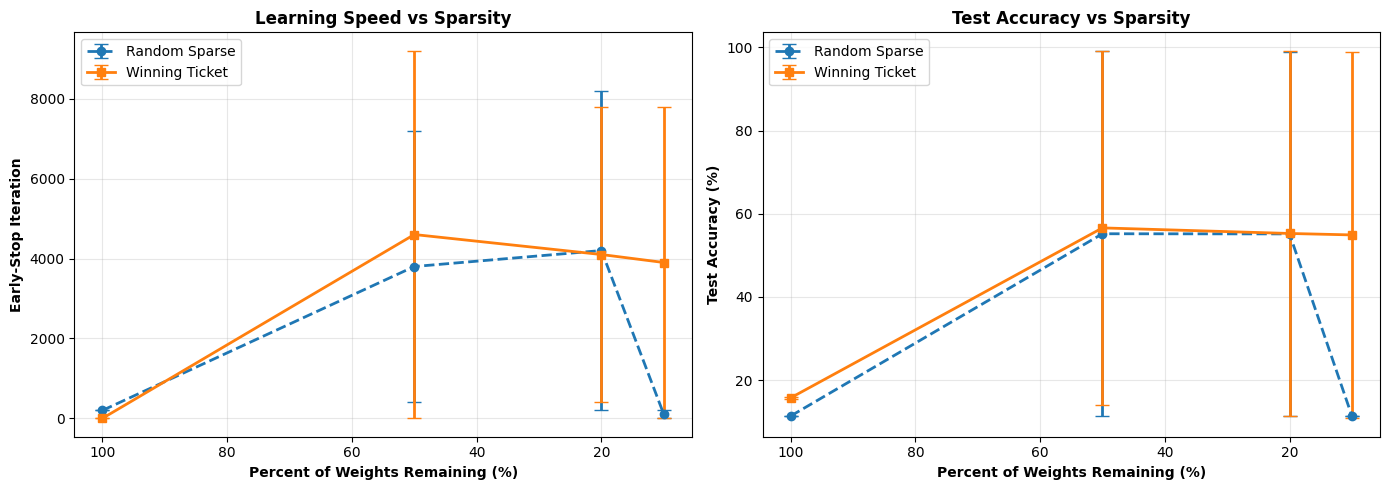

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os


RESULTS_DIR = "./results/conv4/minimal"   
EXP1_PATH = os.path.join(RESULTS_DIR, "exp1_random_sparse.pt")
EXP2_PATH = os.path.join(RESULTS_DIR, "exp2_oneshot_winning.pt")

exp1 = torch.load(EXP1_PATH, weights_only=False)
exp2 = torch.load(EXP2_PATH, weights_only=False)

print("Loaded:")
print("Exp1 sparsities:", list(exp1.keys()))
print("Exp2 sparsities:", list(exp2.keys()))

sparsities = sorted(exp1.keys(), reverse=True)
sparsities_pct = [s * 100 for s in sparsities]

def collect_stats(exp):
    early_mean, early_std = [], []
    acc_mean, acc_std = [], []

    for s in sparsities:
        trials = exp[s]
        early = [t["early_stop_iter"] for t in trials]
        acc   = [t["early_stop_test_acc"] for t in trials]

        early_mean.append(np.mean(early))
        early_std.append(np.std(early) if len(early) > 1 else 0)

        acc_mean.append(np.mean(acc))
        acc_std.append(np.std(acc) if len(acc) > 1 else 0)

    return early_mean, early_std, acc_mean, acc_std

r_early, r_early_err, r_acc, r_acc_err = collect_stats(exp1)
w_early, w_early_err, w_acc, w_acc_err = collect_stats(exp2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.errorbar(
    sparsities_pct, r_early, yerr=r_early_err,
    fmt="o--", linewidth=2, capsize=5, label="Random Sparse"
)
ax1.errorbar(
    sparsities_pct, w_early, yerr=w_early_err,
    fmt="s-", linewidth=2, capsize=5, label="Winning Ticket"
)

ax1.set_xlabel("Percent of Weights Remaining (%)", fontweight="bold")
ax1.set_ylabel("Early-Stop Iteration", fontweight="bold")
ax1.set_title("Learning Speed vs Sparsity", fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.invert_xaxis()

ax2.errorbar(
    sparsities_pct, r_acc, yerr=r_acc_err,
    fmt="o--", linewidth=2, capsize=5, label="Random Sparse"
)
ax2.errorbar(
    sparsities_pct, w_acc, yerr=w_acc_err,
    fmt="s-", linewidth=2, capsize=5, label="Winning Ticket"
)

ax2.set_xlabel("Percent of Weights Remaining (%)", fontweight="bold")
ax2.set_ylabel("Test Accuracy (%)", fontweight="bold")
ax2.set_title("Test Accuracy vs Sparsity", fontweight="bold")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.invert_xaxis()

plt.tight_layout()
plt.show()


Conv4 CIFAR-10 | Single-file Baseline + Iterative Pruning
Device: cuda
Seed: 42
Out dir: ./results_conv4_single
Config:
  batch_size=128 lr=0.0002 weight_decay=0.0
  baseline_epochs=30
  rounds=10 epochs_per_round=15 prune_fraction_per_round=0.2


100%|██████████| 170M/170M [01:39<00:00, 1.71MB/s] 


Dataset: train=45000 val=5000 test=10000
Batches/epoch: 352

[1] Baseline training (Conv4)
Total parameters: 2,425,930
  epoch   1/30 | train_loss=1.5233 | val_acc=56.54% | test_acc=55.92%
  epoch   6/30 | train_loss=0.5418 | val_acc=73.50% | test_acc=71.28%
  epoch  12/30 | train_loss=0.0766 | val_acc=73.98% | test_acc=73.50%
  epoch  18/30 | train_loss=0.0441 | val_acc=72.34% | test_acc=71.91%
  epoch  24/30 | train_loss=0.0299 | val_acc=73.16% | test_acc=72.80%
  epoch  30/30 | train_loss=0.0162 | val_acc=74.22% | test_acc=73.74%

Baseline DONE | test_acc=73.74% | test_loss=1.9295


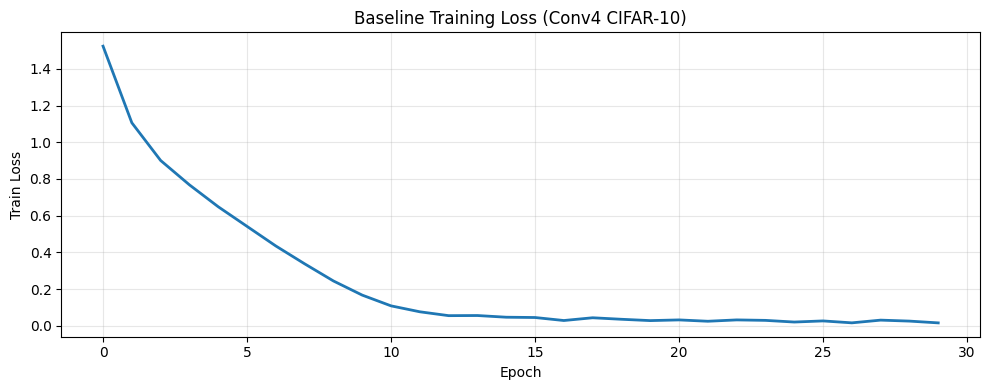


[2] Iterative magnitude pruning + weight rewinding (LTH style)
Prunable parameters (initial): 2,425,024
Round 00 | remaining=100.00% (2,425,024) | test_acc= 74.38% | test_loss=1.3547
Round 01 | remaining= 80.00% (1,940,019) | test_acc= 74.49% | test_loss=1.4327
Round 02 | remaining= 84.00% (2,037,021) | test_acc= 74.72% | test_loss=1.3942
Round 03 | remaining= 83.20% (2,017,620) | test_acc= 74.32% | test_loss=1.4485
Round 04 | remaining= 83.36% (2,021,500) | test_acc= 74.32% | test_loss=1.5183
Round 05 | remaining= 83.33% (2,020,724) | test_acc= 74.37% | test_loss=1.4748
Round 06 | remaining= 83.33% (2,020,880) | test_acc= 74.84% | test_loss=1.3889
Round 07 | remaining= 83.33% (2,020,848) | test_acc= 74.18% | test_loss=1.5376
Round 08 | remaining= 83.33% (2,020,855) | test_acc= 73.43% | test_loss=1.4859
Round 09 | remaining= 83.33% (2,020,853) | test_acc= 73.92% | test_loss=1.4841
Round 10 | remaining= 83.33% (2,020,854) | test_acc= 74.32% | test_loss=1.4204

[3] Plots + JSON save


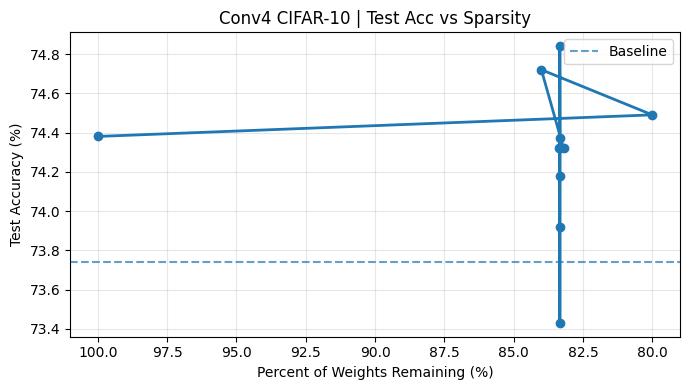

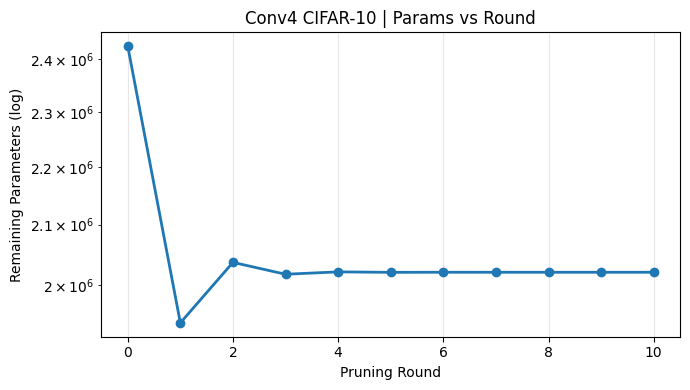


Winning tickets (>= 0.98 * baseline): 11
Best ticket:
  round: 1
  remaining_params_pct: 80.00%
  remaining_params: 1,940,019
  test_accuracy: 74.49%

Saved JSON: ./results_conv4_single\conv4_cifar10_pruning_results.json
Saved figs to: ./results_conv4_single\figs

✅ DONE


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import json
import math
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt


SEED = 42
DATA_DIR = "./data"
OUT_DIR = "./results_conv4_single"
FIG_DIR = os.path.join(OUT_DIR, "figs")

BATCH_SIZE = 128
LR = 2e-4
WEIGHT_DECAY = 0.0
EPOCHS_BASELINE = 30

N_ROUNDS = 10
EPOCHS_PER_ROUND = 15

PRUNE_FRACTION_PER_ROUND = 0.2 

PRUNE_ONLY_WEIGHTS = True

DEVICE_STR = "cuda" 
def ensure_dir(p: str):
    os.makedirs(p, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def get_device(device_str: str):
    if device_str == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

@torch.no_grad()
def eval_accuracy(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return 100.0 * correct / max(total, 1)

@torch.no_grad()
def eval_loss(model: nn.Module, loader: DataLoader, device: torch.device) -> float:
    model.eval()
    ce = nn.CrossEntropyLoss()
    total_loss, total_n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = ce(logits, y)
        bs = y.size(0)
        total_loss += loss.item() * bs
        total_n += bs
    return total_loss / max(total_n, 1)

def train_one_epoch(model: nn.Module, loader: DataLoader, optimizer, device: torch.device, mask=None):
    model.train()
    ce = nn.CrossEntropyLoss()
    running = 0.0
    n = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = ce(logits, y)
        loss.backward()
        optimizer.step()

        if mask is not None:
            apply_mask_(model, mask)

        bs = y.size(0)
        running += loss.item() * bs
        n += bs
    return running / max(n, 1)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())

def count_remaining_params(mask: dict) -> int:
    total = 0
    for v in mask.values():
        total += int(v.sum().item())
    return total

def clone_state_dict(model: nn.Module):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

def load_state_dict_(model: nn.Module, state: dict):
    model.load_state_dict(state, strict=True)

def init_xavier_(model: nn.Module):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)


class Conv4(nn.Module):

    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, 3, padding=1)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, 3, padding=1)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 10)

        init_xavier_(self)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x)     # 32->16

        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.pool(x)     # 16->8

        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def prunable_named_params(model: nn.Module):

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        if PRUNE_ONLY_WEIGHTS:
            if p.dim() >= 2 and ("weight" in name):
                yield name, p
        else:
            yield name, p

def make_ones_mask(model: nn.Module):
    return {n: torch.ones_like(p, dtype=torch.float32) for n, p in prunable_named_params(model)}

def apply_mask_(model: nn.Module, mask: dict):
    with torch.no_grad():
        for n, p in prunable_named_params(model):
            p.mul_(mask[n].to(p.device))

def global_magnitude_prune(mask: dict, model: nn.Module, prune_fraction: float):

    scores = []
    chunks = []  
    for n, p in prunable_named_params(model):
        w = p.detach().abs().cpu()
        m = mask[n].detach().cpu()
        active = (m > 0)
        if active.any():
            scores.append(w[active].flatten())
        chunks.append((n, w, m))

    if len(scores) == 0:
        return {k: v.clone() for k, v in mask.items()}

    scores = torch.cat(scores)
    active_count = scores.numel()
    prune_count = int(math.floor(prune_fraction * active_count))
    prune_count = max(0, min(prune_count, active_count - 1))  

    if prune_count == 0:
        return {k: v.clone() for k, v in mask.items()}

    thresh = torch.kthvalue(scores, prune_count).values.item()

    new_mask = {}
    for n, w, m in chunks:
        active = (m > 0)
        keep = torch.ones_like(m)
        keep[active & (w <= thresh)] = 0.0
        new_mask[n] = keep.float()

    return new_mask

def main():
    ensure_dir(DATA_DIR)
    ensure_dir(OUT_DIR)
    ensure_dir(FIG_DIR)

    set_seed(SEED)
    device = get_device(DEVICE_STR)

    print("=" * 70)
    print("Conv4 CIFAR-10 | Single-file Baseline + Iterative Pruning")
    print("=" * 70)
    print("Device:", device)
    print("Seed:", SEED)
    print("Out dir:", OUT_DIR)
    print("Config:")
    print(f"  batch_size={BATCH_SIZE} lr={LR} weight_decay={WEIGHT_DECAY}")
    print(f"  baseline_epochs={EPOCHS_BASELINE}")
    print(f"  rounds={N_ROUNDS} epochs_per_round={EPOCHS_PER_ROUND} prune_fraction_per_round={PRUNE_FRACTION_PER_ROUND}")
    print("=" * 70)

    tf_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    full_train = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=tf_train)
    test_set = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=tf_test)

    train_size, val_size = 45000, 5000
    train_set, val_set = random_split(full_train, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"Dataset: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
    print(f"Batches/epoch: {len(train_loader)}")

    print("\n" + "=" * 70)
    print("[1] Baseline training (Conv4)")
    print("=" * 70)

    baseline_model = Conv4().to(device)
    print("Total parameters:", f"{count_params(baseline_model):,}")

    opt = optim.Adam(baseline_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    baseline_train_losses = []
    for ep in range(1, EPOCHS_BASELINE + 1):
        loss = train_one_epoch(baseline_model, train_loader, opt, device, mask=None)
        baseline_train_losses.append(loss)

        if ep % max(1, EPOCHS_BASELINE // 5) == 0 or ep == 1:
            va_acc = eval_accuracy(baseline_model, val_loader, device)
            te_acc = eval_accuracy(baseline_model, test_loader, device)
            print(f"  epoch {ep:3d}/{EPOCHS_BASELINE} | train_loss={loss:.4f} | val_acc={va_acc:.2f}% | test_acc={te_acc:.2f}%")

    baseline_test_acc = eval_accuracy(baseline_model, test_loader, device)
    baseline_test_loss = eval_loss(baseline_model, test_loader, device)
    print(f"\nBaseline DONE | test_acc={baseline_test_acc:.2f}% | test_loss={baseline_test_loss:.4f}")

    plt.figure(figsize=(10, 4))
    plt.plot(baseline_train_losses, linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Train Loss")
    plt.title("Baseline Training Loss (Conv4 CIFAR-10)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    baseline_loss_fig = os.path.join(FIG_DIR, "baseline_train_loss.png")
    plt.savefig(baseline_loss_fig, dpi=150)
    plt.show()

    init_model = Conv4().to(device)
    init_state = clone_state_dict(init_model)  
    del init_model

    torch.save({"model_state": baseline_model.state_dict(),
                "test_acc": baseline_test_acc,
                "test_loss": baseline_test_loss},
               os.path.join(OUT_DIR, "baseline_checkpoint.pt"))

    print("\n" + "=" * 70)
    print("[2] Iterative magnitude pruning + weight rewinding (LTH style)")
    print("=" * 70)

    work_model = Conv4().to(device)

    mask = make_ones_mask(work_model)
    total_prunable = count_remaining_params(mask)
    print("Prunable parameters (initial):", f"{total_prunable:,}")

    round_records = []

    remaining_pct_list = []
    test_acc_list = []
    remaining_params_list = []

    for r in range(0, N_ROUNDS + 1):
        load_state_dict_(work_model, init_state)
        apply_mask_(work_model, mask)

        opt_r = optim.Adam(work_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

        losses_r = []
        for ep in range(1, EPOCHS_PER_ROUND + 1):
            loss = train_one_epoch(work_model, train_loader, opt_r, device, mask=mask)
            losses_r.append(loss)

        te_acc = eval_accuracy(work_model, test_loader, device)
        te_loss = eval_loss(work_model, test_loader, device)
        rem = count_remaining_params(mask)
        rem_pct = 100.0 * rem / max(total_prunable, 1)

        print(f"Round {r:02d} | remaining={rem_pct:6.2f}% ({rem:,}) | test_acc={te_acc:6.2f}% | test_loss={te_loss:.4f}")

        round_records.append({
            "round": int(r),
            "remaining_params": int(rem),
            "remaining_params_pct": float(rem_pct),
            "test_accuracy": float(te_acc),
            "test_loss": float(te_loss),
            "train_loss_last": float(losses_r[-1] if len(losses_r) else 0.0),
        })

        remaining_pct_list.append(rem_pct)
        remaining_params_list.append(rem)
        test_acc_list.append(te_acc)

        if r == N_ROUNDS:
            break

        mask = global_magnitude_prune(mask, work_model, prune_fraction=PRUNE_FRACTION_PER_ROUND)

    print("\n" + "=" * 70)
    print("[3] Plots + JSON save")
    print("=" * 70)

    plt.figure(figsize=(7, 4))
    plt.plot(remaining_pct_list, test_acc_list, "o-", linewidth=2)
    plt.axhline(y=baseline_test_acc, linestyle="--", alpha=0.7, label="Baseline")
    plt.xlabel("Percent of Weights Remaining (%)")
    plt.ylabel("Test Accuracy (%)")
    plt.title("Conv4 CIFAR-10 | Test Acc vs Sparsity")
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()
    plt.legend()
    plt.tight_layout()
    fig1 = os.path.join(FIG_DIR, "acc_vs_remaining_pct.png")
    plt.savefig(fig1, dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot([x["round"] for x in round_records], remaining_params_list, "o-", linewidth=2)
    plt.yscale("log")
    plt.xlabel("Pruning Round")
    plt.ylabel("Remaining Parameters (log)")
    plt.title("Conv4 CIFAR-10 | Params vs Round")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fig2 = os.path.join(FIG_DIR, "params_vs_round.png")
    plt.savefig(fig2, dpi=150)
    plt.show()

    threshold = baseline_test_acc * 0.98
    winners = [rr for rr in round_records if rr["test_accuracy"] >= threshold]

    if len(winners) > 0:
        best = min(winners, key=lambda x: x["remaining_params"])
        print("\nWinning tickets (>= 0.98 * baseline):", len(winners))
        print("Best ticket:")
        print("  round:", best["round"])
        print("  remaining_params_pct:", f"{best['remaining_params_pct']:.2f}%")
        print("  remaining_params:", f"{best['remaining_params']:,}")
        print("  test_accuracy:", f"{best['test_accuracy']:.2f}%")
    else:
        print("\nNo winning tickets found at >= 0.98 * baseline (normal olabilir).")

    out = {
        "seed": SEED,
        "device": str(device),
        "dataset": "CIFAR-10",
        "model": "Conv4",
        "baseline": {
            "epochs": EPOCHS_BASELINE,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "weight_decay": WEIGHT_DECAY,
            "test_acc": float(baseline_test_acc),
            "test_loss": float(baseline_test_loss),
        },
        "pruning": {
            "rounds": N_ROUNDS,
            "epochs_per_round": EPOCHS_PER_ROUND,
            "prune_fraction_per_round": PRUNE_FRACTION_PER_ROUND,
            "prune_only_weights": PRUNE_ONLY_WEIGHTS,
            "total_prunable_params": int(total_prunable),
            "records": round_records,
            "winning_threshold": float(threshold),
            "winning_tickets": winners,
        },
        "files": {
            "fig_acc_vs_remaining_pct": fig1,
            "fig_params_vs_round": fig2,
            "fig_baseline_loss": baseline_loss_fig,
        }
    }

    json_path = os.path.join(OUT_DIR, "conv4_cifar10_pruning_results.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(out, f, indent=2)

    print("\nSaved JSON:", json_path)
    print("Saved figs to:", FIG_DIR)
    print("\n✅ DONE")


if __name__ == "__main__":
    main()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _get_curve_obj(res, t, i, kr):

    try:
        return res[t][i]
    except Exception:
        pass

    try:
        return res[t][kr]
    except Exception:
        pass

    raise KeyError("a.")

def points_from_res(res, keep_ratios, prefer="test", pick="last"):

    key_candidates = {
        "test":  ["test_accs", "test_acc", "test_accuracy", "test_accuracies"],
        "val":   ["val_accs", "val_acc", "val_accuracy", "val_accuracies"],
        "train": ["train_accs", "train_acc", "train_accuracy", "train_accuracies"],
    }[prefer]

    T = len(res)
    K = len(keep_ratios)
    Y = np.zeros((T, K), dtype=float)

    for t in range(T):
        for i, kr in enumerate(keep_ratios):
            curve = _get_curve_obj(res, t, i, kr)

            series = None
            for k in key_candidates:
                if k in curve:
                    series = curve[k]
                    break
            if series is None:
                raise KeyError(f"Curve dict içinde {key_candidates} bulunamadı. Mevcut keys: {list(curve.keys())}")

            series = np.asarray(series).reshape(-1)
            if pick == "last":
                Y[t, i] = series[-1]
            elif pick == "best":
                Y[t, i] = series.max()
            else:
                raise ValueError("pick 'last' veya 'best' olmalı.")
    return Y

def plot_ticket_vs_random(keep_ratios, random_res, ticket_res=None, prefer="test", pick="last"):
    x = np.asarray(keep_ratios)

    Yr = points_from_res(random_res, keep_ratios, prefer=prefer, pick=pick)
    plt.figure()
    for t in range(Yr.shape[0]):
        plt.plot(x, Yr[t], linestyle="--", alpha=0.7)
    plt.plot(x, Yr.mean(axis=0), linewidth=2, label=f"Random mean ({prefer}, {pick})")

    if ticket_res is not None:
        Yt = points_from_res(ticket_res, keep_ratios, prefer=prefer, pick=pick)
        for t in range(Yt.shape[0]):
            plt.plot(x, Yt[t], linestyle="-", alpha=0.7)
        plt.plot(x, Yt.mean(axis=0), linewidth=3, label=f"Ticket mean ({prefer}, {pick})")

    plt.xlabel("Weights remaining (keep_ratio)")
    plt.ylabel(f"{prefer} accuracy")
    plt.xscale("log") 
    plt.grid(True, which="both", linestyle=":", alpha=0.5)
    plt.legend()
    plt.show()



In [ ]:
[x for x in globals().keys() if "random" in x.lower()]


['random',
 'random_split',
 'random_sparse_mask_like',
 'exp1_random_sparse',
 'plot_ticket_vs_random']

In [57]:
exp1_random_sparse


<function __main__.exp1_random_sparse(config, loaders, device) -> Dict[float, List[Dict[str, Any]]]>

In [ ]:
random_res = exp1_random_sparse 

plot_ticket_vs_random(
    keep_ratios=keep_ratios,
    random_res=random_res,
    ticket_res=None,       
    prefer="test",
    pick="last"        
)


NameError: name 'keep_ratios' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

random_res = exp1_random_sparse(config, loaders, device)  

x = np.array(sorted(random_res.keys()))

def pick_one(curve_dict, prefer="test", pick="last"):
    key_map = {
        "test":  ["test_accs", "test_acc", "test_accuracy", "test_accuracies"],
        "val":   ["val_accs", "val_acc", "val_accuracy", "val_accuracies"],
        "train": ["train_accs", "train_acc", "train_accuracy", "train_accuracies"],
    }[prefer]

    series = None
    for k in key_map:
        if k in curve_dict:
            series = curve_dict[k]
            break
    if series is None:
        raise KeyError(f"Curve dict içinde {key_map} bulunamadı. Mevcut keys: {list(curve_dict.keys())}")

    s = np.asarray(series).reshape(-1)
    if pick == "last":
        return float(s[-1])
    elif pick == "best":
        return float(s.max())
    else:
        raise ValueError("pick 'last' veya 'best' olmalı.")

n_trials = max(len(random_res[kr]) for kr in x)
Y = np.full((n_trials, len(x)), np.nan)

for j, kr in enumerate(x):
    curves = random_res[kr]       
    for t, curve in enumerate(curves):
        Y[t, j] = pick_one(curve, prefer="test", pick="last") 

plt.figure()
for t in range(n_trials):
    if np.all(np.isnan(Y[t])): 
        continue
    plt.plot(x, Y[t], linestyle="--", alpha=0.7)

plt.plot(x, np.nanmean(Y, axis=0), linewidth=3, label="Random mean")

plt.xlabel("Weights remaining (keep_ratio)")
plt.ylabel("Test accuracy")
plt.xscale("log")  
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.legend()
plt.show()


NameError: name 'config' is not defined

In [ ]:
[k for k in globals().keys() if "config" in k.lower() or k.lower() in ["cfg", "conf"]]


['get_config', 'cfg']

In [ ]:
[k for k in globals().keys() if "loader" in k.lower() or "dataloader" in k.lower() or "loaders" in k.lower()]


['__loader__', 'DataLoader']

In [ ]:
[k for k in globals().keys() if "device" in k.lower()]


['get_device', 'DEVICE_STR']

In [ ]:
device = get_device()   
device


TypeError: get_device() missing 1 required positional argument: 'device_str'